# ***Importing Libraries***

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import tensorflow

#Loadig dataset.

from datasets import load_dataset

In [2]:
load_dataset("dair-ai/emotion")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [3]:
emotions_dataset = load_dataset("dair-ai/emotion") #Storing inot variable

In [4]:
train_text = emotions_dataset['train']['text']
train_label = emotions_dataset['train']['label']

test_text = emotions_dataset['test']['text']
text_label = emotions_dataset['test']['label']

In [5]:
label_name = emotions_dataset['train'].features['label'].names

In [6]:
df_train = pd.DataFrame(
    {
    'text' : train_text,
    'label' : [label_name[i] for i in train_label]
   }
    )

# df_train.head()

df_test = pd.DataFrame(
      {
    'text' : test_text,
    'label' : [label_name[i] for i in text_label]
      }
      )

# df_test.head()

# ***Exploratory Data Analysis***

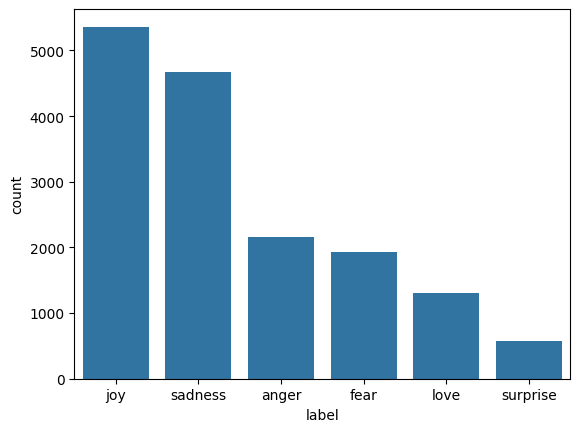

In [7]:
sns.countplot(data=df_train, x = 'label', order=df_train['label'].value_counts().index)
plt.show()

# ***Data Preprocessing-Using NLP***

In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000 #Chunk_Size

tokenizer = Tokenizer(num_words = max_words, oov_token = '<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequences = tokenizer.texts_to_sequences(df_train['text']) #Removing text.
test_sequences = tokenizer.texts_to_sequences(df_test['text'])

Padded_train_sequence = pad_sequences(train_sequences, maxlen=50, padding='post', truncating='post') #Padding
Padded_test_sequence = pad_sequences(test_sequences, maxlen=50, padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels = np.array(text_label)

num_classes = len(np.unique(train_labels)) #Number of classes i.e 6

print('Vocabulary size', len(tokenizer.word_index))
print('Max Sentence length', Padded_train_sequence.shape[1])

Vocabulary size 15213
Max Sentence length 50


# ***Shared Training Utilities***

In [9]:
from sklearn.utils import class_weight

"""
    weight = Total_Samples/(Number_of_Classes * Sample_in_that_Class)

"""

class_weight = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      =  np.unique(train_labels),
    y            =  train_labels
)

class_weight_dict = dict(enumerate(class_weight))

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor = 'val_loss',
                              patience = 3,
                  restore_best_weights = True)

# ***Plain Foundation Model -  RNN***

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU


rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_shape=(50,)),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation = 'softmax') #output layer
])

rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
rnn_model.fit(Padded_train_sequence,
              train_labels,
              validation_data = (Padded_test_sequence, test_labels),
              epochs = 20,
              batch_size = 32,
              # validation_split = 0.2,
              class_weight = class_weight_dict,
              callbacks = [early_stopping]
          )

rnn_loss, rnn_accuracy = rnn_model.evaluate(Padded_test_sequence, test_labels)
print('RNN Loss =', rnn_loss)
print('RNN Accuracy = ', rnn_accuracy)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.1587 - loss: 1.8985 - val_accuracy: 0.1330 - val_loss: 1.8131
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1649 - loss: 1.8002 - val_accuracy: 0.0905 - val_loss: 1.8192
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.1693 - loss: 1.7835 - val_accuracy: 0.1430 - val_loss: 1.8068
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.1639 - loss: 1.7744 - val_accuracy: 0.0870 - val_loss: 1.8145
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1566 - loss: 1.7598 - val_accuracy: 0.1240 - val_loss: 1.7898
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1602 - loss: 1.7513 - val_accuracy: 0.1330 - val_loss: 1.7799
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1581 - loss: 1.7557 - val_accuracy: 0.0950 - val_loss: 1.8926
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1622 - loss: 1.7278 - val_acc

# ***Standard LSTM***

In [13]:

lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_shape=(50,)),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation = 'softmax') #output layer
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [14]:
lstm_model.fit(Padded_train_sequence,
              train_labels,
              validation_data = (Padded_test_sequence, test_labels),
              epochs = 20,
              batch_size = 32,
              # validation_split = 0.2,
              class_weight = class_weight_dict,
              callbacks = [early_stopping]
          )

lstm_loss, lstm_accuracy = lstm_model.evaluate(Padded_test_sequence, test_labels)
print('LSTM Loss =', lstm_loss)
print('LSTM Accuracy = ', lstm_accuracy)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.1472 - loss: 1.7951 - val_accuracy: 0.2885 - val_loss: 1.7777
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1549 - loss: 1.7940 - val_accuracy: 0.3330 - val_loss: 1.7869
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1443 - loss: 1.7925 - val_accuracy: 0.0340 - val_loss: 1.7978
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2885 - loss: 1.7777
LSTM Loss = 1.777677059173584
LSTM Accuracy =  0.28850001096725464


# ***Standard GRU***

In [15]:
gru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_shape=(50,)),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation = 'softmax') #output layer
])

gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [16]:
gru_model.fit(Padded_train_sequence,
              train_labels,
              validation_data = (Padded_test_sequence, test_labels),
              epochs = 20,
              batch_size = 32,
              # validation_split = 0.2,
              class_weight = class_weight_dict,
              callbacks = [early_stopping]
          )

gru_loss, gru_accuracy = gru_model.evaluate(Padded_test_sequence, test_labels)
print('GRU Loss =', gru_loss)
print('GRU Accuracy = ', gru_accuracy)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.1594 - loss: 1.7963 - val_accuracy: 0.0335 - val_loss: 1.8023
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1702 - loss: 1.7949 - val_accuracy: 0.0830 - val_loss: 1.7996
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1653 - loss: 1.7948 - val_accuracy: 0.0315 - val_loss: 1.8238
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0335 - loss: 1.8023
GRU Loss = 1.8022935390472412
GRU Accuracy =  0.03350000083446503


In [17]:
result_df = pd.DataFrame({
              'Model' : ['RNN', 'LSTM', 'GRU'],
              'Test Loss' : [rnn_loss, lstm_loss, gru_loss],
              'Test Accuracy' : [rnn_accuracy, lstm_accuracy, gru_accuracy]
              }).sort_values(by='Test Accuracy', ascending = False)
result_df

,Model,Test Loss,Test Accuracy
0,RNN,1.758104,0.3170
1,LSTM,1.777677,0.2885
2,GRU,1.802294,0.0335


# ***Advance Bidirectional GRU***

In [20]:
# Left -> right + right -> left
# ------------>   <-------------

from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300, input_shape = (50,)),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
BiGRU.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 50, 300)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 50, 256)        │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,454,662 (13.18 MB)

 Trainable params: 3,454,662 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
BiGRU.fit(Padded_train_sequence,
          train_labels,
          validation_data = (Padded_test_sequence, test_labels),
          epochs = 20,
          batch_size = 32,
          class_weight = class_weight_dict,
          callbacks = [early_stopping]
    )

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5794 - loss: 0.9938 - val_accuracy: 0.8965 - val_loss: 0.3045
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9184 - loss: 0.2358 - val_accuracy: 0.9140 - val_loss: 0.2505
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9416 - loss: 0.1497 - val_accuracy: 0.9250 - val_loss: 0.2127
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9604 - loss: 0.1084 - val_accuracy: 0.9225 - val_loss: 0.2552
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9741 - loss: 0.0723 - val_accuracy: 0.9170 - val_loss: 0.2493
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9754 - loss: 0.0691 - val_accuracy: 0.9085 - val_loss: 0.3300


In [22]:
bigru_loss, bigru_accuracy = BiGRU.evaluate(Padded_test_sequence, test_labels)
print('BiGRU Loss =', bigru_loss)
print('GRU Accuracy = ', bigru_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9250 - loss: 0.2127
BiGRU Loss = 0.2126733660697937
GRU Accuracy =  0.925000011920929


## ***Confusin Metrics***

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


<Axes: >

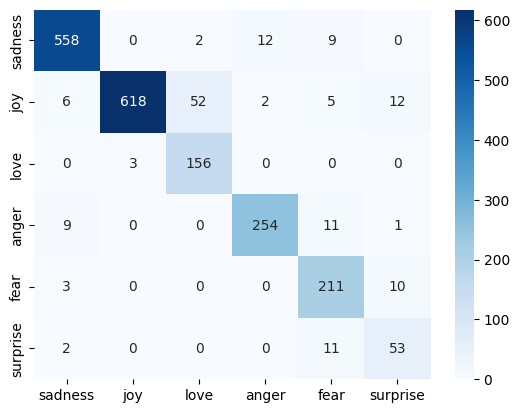

In [32]:
from sklearn.metrics import confusion_matrix

BiGRU_predections = np.argmax(BiGRU.predict(Padded_test_sequence), axis = 1)

#HeatMap

sns.heatmap(confusion_matrix(test_labels,
                             BiGRU_predections),
                             annot=True, fmt='d',
                              cmap='Blues',
                              xticklabels=label_name,
                              yticklabels=label_name
                              )

# ***Final predections***

In [37]:
sample_texts = [
"I can't believe how happy I am right now, this is amazing!",
"I feel so alone and hopeless today.",
"I am furious that they cancelled the trip at the last minute.",
"I feel terrified when walking down dark alleyways alone.",
"I was shocked and completely surprised by the unexpected gift!"]

#Text to Number
sample_sequences = tokenizer.texts_to_sequences(sample_texts)
padded_sample_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

#Predections
sample_predections = np.argmax(BiGRU.predict(padded_sample_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text - {sample_texts[i]}\nPredicated Emotions - {label_name[sample_predections[i]]}\n')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Text - I can't believe how happy I am right now, this is amazing!
Predicated Emotions - surprise

Text - I feel so alone and hopeless today.
Predicated Emotions - sadness

Text - I am furious that they cancelled the trip at the last minute.
Predicated Emotions - anger

Text - I feel terrified when walking down dark alleyways alone.
Predicated Emotions - fear

Text - I was shocked and completely surprised by the unexpected gift!
Predicated Emotions - surprise



# ***Save Model & Toeknizer***

In [49]:
# import os
# import pickle

# model_dir = 'Artifacts'
# os.makedirs(model_dir, exist_ok=True)

# # Saving BiGRU model
# BiGRU.save(os.path.join(model_dir, 'BiGRU_model.keras'))

# #saving tokenizer model
# with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
#   pickle.dump(tokenizer, file)